<center><h1> Agent-Based Model of Panic</h1> </center>

## Imports

In [1]:
import random
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
from scipy import stats
import statistics
import math
import numpy as np
import seaborn as sns

In [2]:
plt.rc('figure', figsize=(12, 8))
plt.rcParams['font.size'] = '24'
#sns.set_style("ticks", {'font.family': 'Times New Roman'})
#sns.set_palette("Paired")

## Model Class

In [3]:
class Model():

    def __init__(self, num_of_agents, num_iterations, agent_groups): 
        
        self.num_of_agents = num_of_agents
        self.num_iterations = num_iterations
        self.agent_groups = agent_groups

        self.time = 0 #model time
        
        #creating lists
        self.num_infected_per_iteration = []
        self.num_infected_per_iteration_groups = []
        
        #create the agents
        self.agents = []
        
        for key in self.agent_groups.keys():
#             print(key)
            for i in range(round(self.agent_groups[key][2] * num_of_agents)):
                agent = Agent(self, key, key[0], key[1])
                agent.beta = self.agent_groups[key][0]
                agent.alpha = self.agent_groups[key][1]
#                 print(agent)
                self.agents.append(agent)
        
        self.infected_per_group = {}
        
        for g in self.agent_groups:
            self.infected_per_group[g] = []
        

    def get_num_infected(self):
        return len(([a for a in self.agents if a.state==1])) 

    def get_num_infected_iteration_groups(self, group_number):
        return len(([ a for a in self.agent_groups[group_number] if a.state==1 ]))
    
    def run(self):
        for t in range(self.num_iterations):
            for agent in self.agents:
                if t >=1:
                    agent.step()
           
            for g in self.agent_groups:
                group_agents = [a for a in self.agents if a.group == g]
                num_infected = sum([a.state for a in group_agents])
                self.infected_per_group[g].append(num_infected)
        
            self.num_infected_per_iteration.append(self.get_num_infected())
        
        
            self.data = pd.DataFrame(self.infected_per_group)
            self.data.reset_index(inplace = True, drop = False)
            
            self.dataset = pd.DataFrame(self.num_infected_per_iteration)
        
            
            self.result = pd.merge(self.data, self.dataset, left_index=True, right_index=True)
            self.result.rename(columns={self.result.columns[-1]: "num_infected" }, inplace = True)
        
    
            self.time += 1


## Agent Class

In [4]:
class Agent():
    
    def __init__(self, model, group, beta=0, alpha=0, gamma=0.1):
        
        #intialising parameters
        self.state = 0
        
        self.alpha = alpha
        self.gamma = gamma
        self.beta = beta 
        
        self.model = model
        
        self.group = group
        
        self.likelihood = 0

    def step(self):
        if self.state == 0:
            self.become_panicked()
            
        else:
            self.recover()
    
    
    def __repr__(self):
        return f"agent beta {self.beta}"
        
    def become_panicked(self):
        
        Agent_i = random.choice(self.model.agents)
        
        if Agent_i.state == 1:
            self.likelihood = self.alpha + self.beta
        else:
            self.likelihood = self.alpha
        
        r_v = random.random()
        if r_v < self.likelihood: 
            self.state = 1

#         for i, agent in enumerate(model.agents):
#             print('Agent {0}/{1}:'.format(i, model.num_of_agents)) 
#             print('Likelihood:{}, my state:{}'.format(self.likelihood, self.state))
            
       
    def recover(self): 
        r_v = random.random()
        if self.state == 1:
            if r_v < self.gamma:
                self.state = 0

## Running model

In [5]:
random.seed(122)

### Homogeneous Config

In [15]:
agent_groups = {'Group1': [0.2, 0.01, 1.0]} #008957
homo_model = Model(num_of_agents=1000, num_iterations=1000, agent_groups=agent_groups)
homo_model.run()

In [22]:
homo_model.result

,index,Group1,num_infected
0,0,0,0
1,1,19,19
2,2,31,31
3,3,52,52
4,4,71,71
...,...,...,...
995,995,560,560
996,996,567,567
997,997,563,563
998,998,563,563


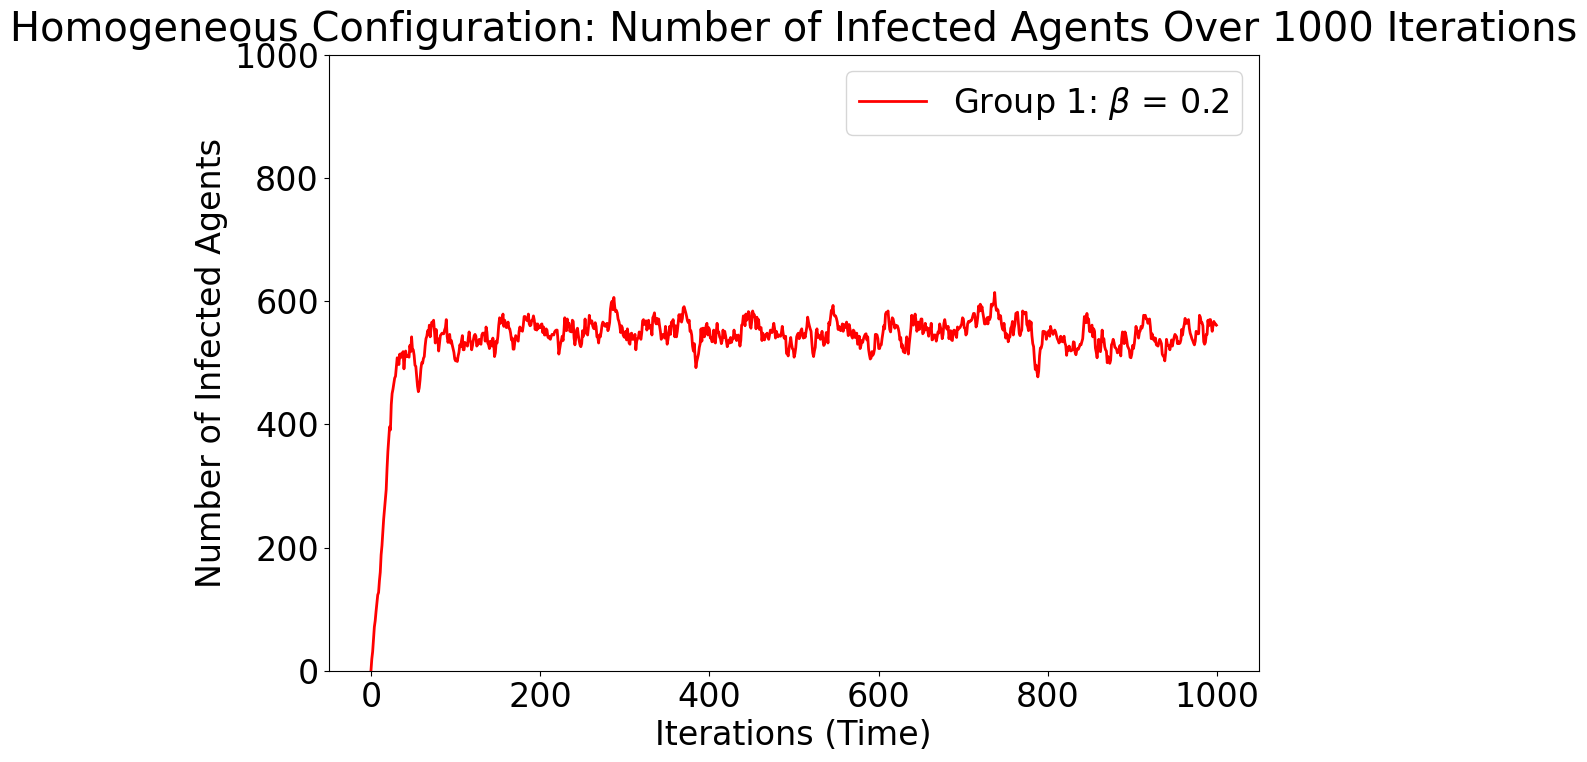

In [36]:
ax = plt.gca()
ax.set_ylim(0,len(homo_model.agents))

for key in agent_groups.keys():
    ax  = plt.plot('index', key, data=homo_model.data, markersize=10, color='red', linewidth=2) #marker = "o",
    plt.title('Homogeneous Configuration: Number of Infected Agents Over 1000 Iterations', pad=10)
    plt.xlabel('Iterations (Time)')
    plt.ylabel('Number of Infected Agents')
    plt.legend(loc="upper right")
    plt.legend(['Group 1: ' r'$ \beta$ = 0.2'])
    plt.savefig("Homo_Config", bbox_inches="tight", dpi=128)

### Heterogeneus Config

In [8]:
agent_groups = {'Group1': [0.2, 0.01, 0.5], 'Group2': [0.6, 0.01, 0.5]} #008957
hete_model = Model(num_of_agents=1000, num_iterations=1000, agent_groups=agent_groups)
hete_model.run()

In [9]:
sns.set_palette("Paired")

In [10]:
hete_model.result

,index,Group1,Group2,num_infected
0,0,0,0,0
1,1,4,9,13
2,2,9,21,30
3,3,11,34,45
4,4,18,57,75
...,...,...,...,...
995,995,292,415,707
996,996,283,411,694
997,997,292,408,700
998,998,297,403,700


/var/folders/g7/q_xw5lt13pj94bfbt43bn03m0000gn/T/ipykernel_11795/3045587483.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


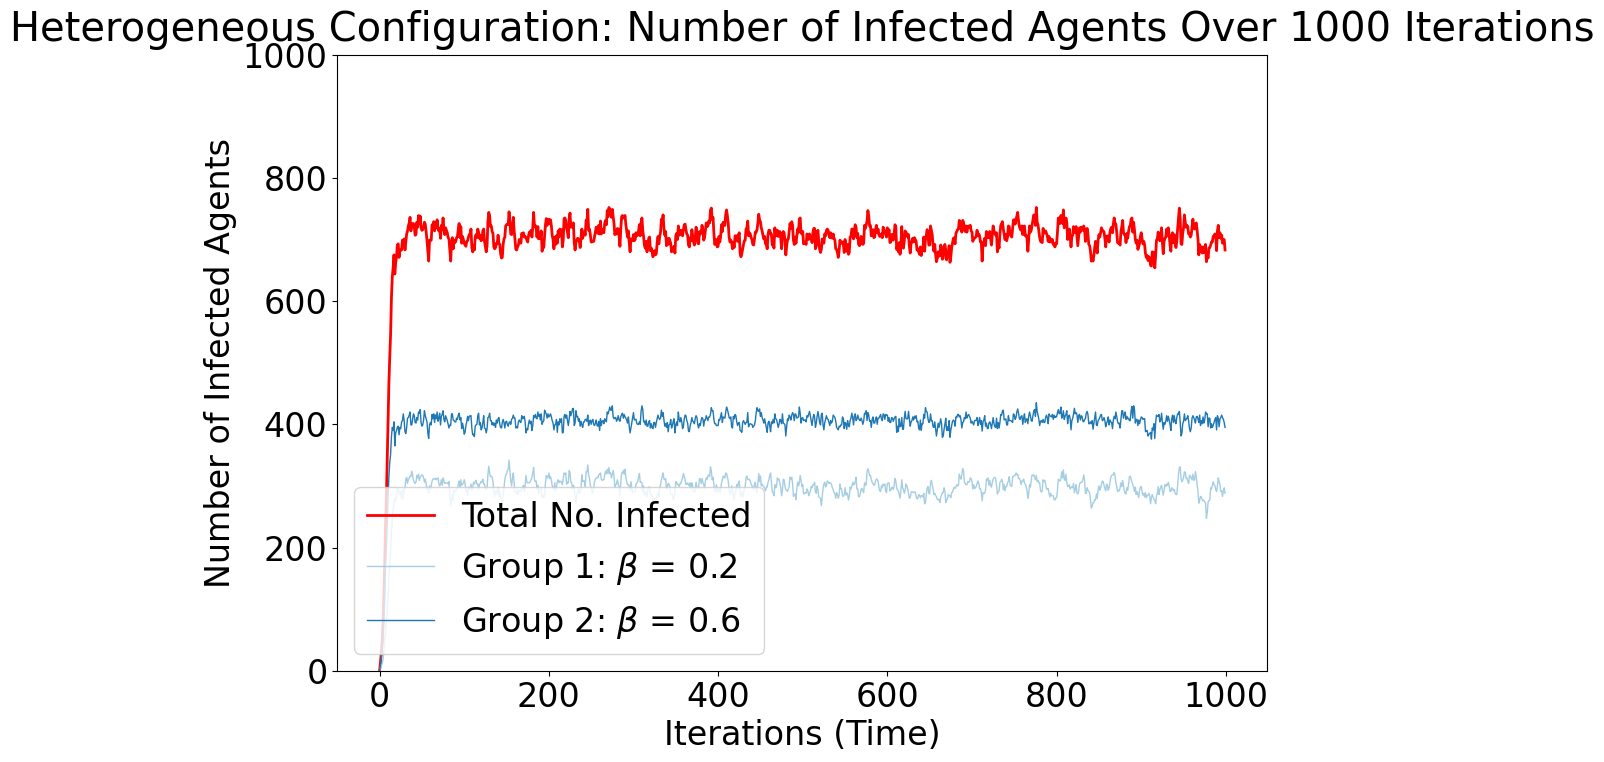

In [34]:
ax = plt.gca()
ax.set_ylim(0,len(hete_model.agents))

sns.lineplot(data=hete_model.result, y="num_infected", x = 'index', color='red', linewidth=2, errorbar= None)
sns.lineplot(data=hete_model.result, y="Group1", x = 'index', linewidth=1, errorbar= None)
sns.lineplot(data=hete_model.result, y="Group2", x = 'index', linewidth=1, errorbar= None)


#for key in agent_groups.keys():
    #ax  = plt.plot('index', key, data=model.data, markersize=10) #marker = "o",
    
plt.title('Heterogeneous Configuration: Number of Infected Agents Over 1000 Iterations', pad=10)
plt.xlabel('Iterations (Time)')
plt.ylabel('Number of Infected Agents')
plt.legend(loc="upper right")
plt.legend(['Total No. Infected', 'Group 1: ' r'$ \beta$ = 0.2','Group 2: ' r'$ \beta$ = 0.6' ])
plt.savefig("Hetero_Config", bbox_inches="tight", dpi=128)

In [24]:
import pandas as pd

# Ensure both have the same time column name
homo_df = homo_model.data.copy().rename(columns={"Group1": "homo_total"})
hete_df = hete_model.result.copy()


In [25]:
print(homo_model.data.columns)


Index(['index', 'Group1'], dtype='object')


In [26]:
# Merge on 'index' (or whatever your iteration column is called)
merged = pd.merge(homo_df[['index', 'homo_total']], 
                  hete_df[['index', 'num_infected', 'Group1', 'Group2']],
                  on='index', how='inner')

print(merged.head())

   index  homo_total  num_infected  Group1  Group2
0      0           0             0       0       0
1      1          19            13       4       9
2      2          31            30       9      21
3      3          52            45      11      34
4      4          71            75      18      57


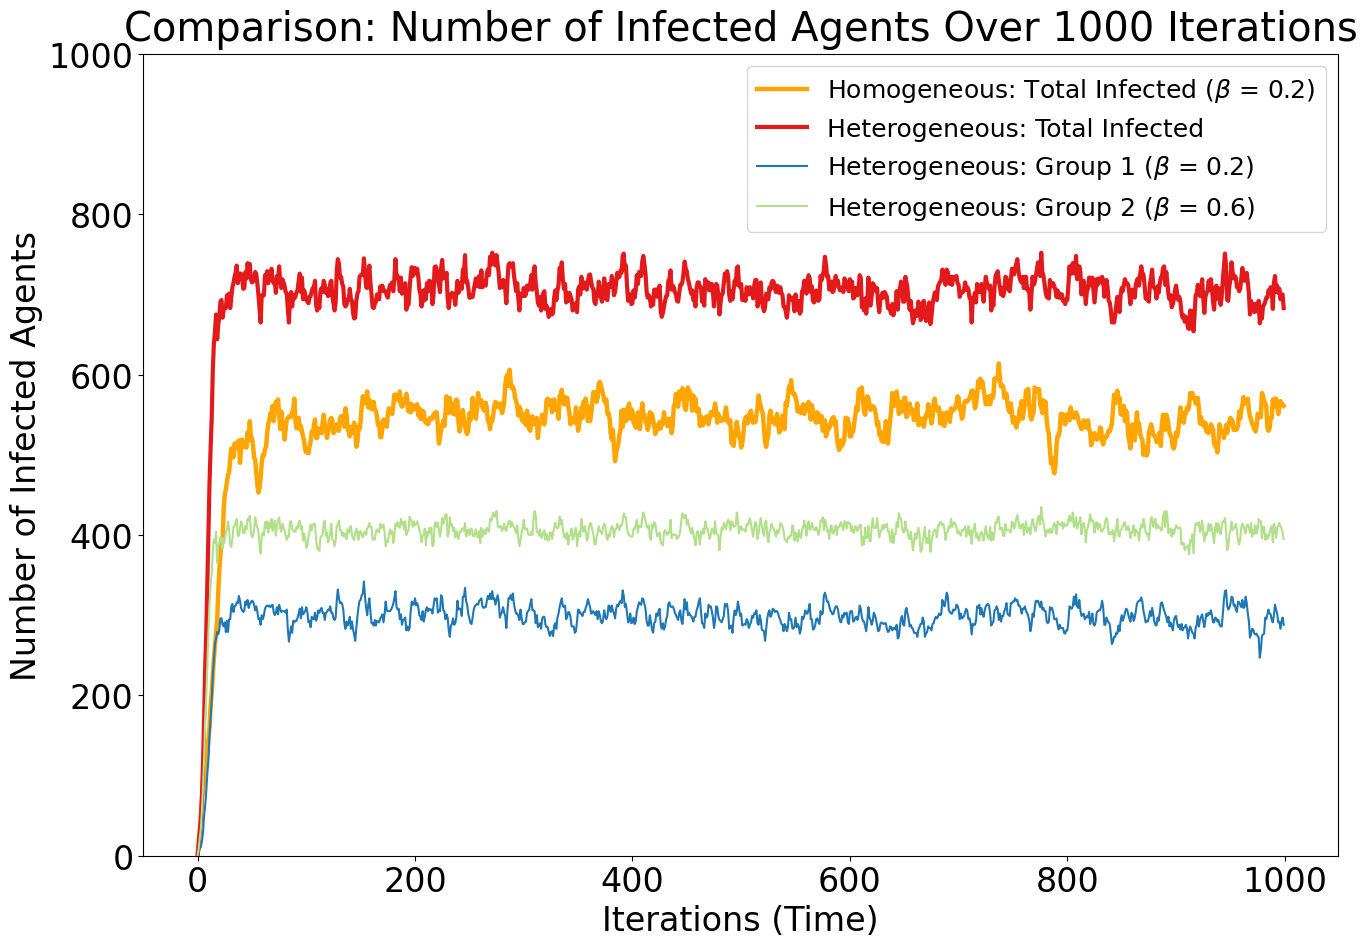

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the 'Paired' color palette for heterogeneous lines
palette = sns.color_palette("Paired", 10)

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_ylim(0, len(hete_model.agents))

# --- Homogeneous total infected (contrasting dashed line) ---
sns.lineplot(
    data=merged, x='index', y='homo_total',
    label='Homogeneous: Total Infected ($\\beta$ = 0.2)',
    linewidth=3.2,color='orange', ax=ax
)

# --- Heterogeneous total infected ---
sns.lineplot(
    data=merged, x='index', y='num_infected',
    label='Heterogeneous: Total Infected',
    linewidth=3, color=palette[5], ax=ax
)

# --- Heterogeneous Group 1 ---
sns.lineplot(
    data=merged, x='index', y='Group1',
    label='Heterogeneous: Group 1 ($\\beta$ = 0.2)',
    linewidth=1.5, color=palette[1], ax=ax
)

# --- Heterogeneous Group 2 ---
sns.lineplot(
    data=merged, x='index', y='Group2',
    label='Heterogeneous: Group 2 ($\\beta$ = 0.6)',
    linewidth=1.5, color=palette[2], ax=ax
)

# --- Final styling ---
ax.set_title('Comparison: Number of Infected Agents Over 1000 Iterations', pad=10)
ax.set_xlabel('Iterations (Time)', fontsize=24)
ax.set_ylabel('Number of Infected Agents', fontsize=24)
ax.legend(loc="upper right", fontsize=18)
ax.grid(False)

plt.tight_layout()

# --- Save the figure ---
plt.savefig("infected_agents_comparison.png", dpi=300, bbox_inches="tight")  # high-res PNG
# plt.savefig("infected_agents_comparison.pdf", bbox_inches="tight")  # optional: vector PDF

plt.show()


## Model Evaluation

In [12]:
data_val = []
for j in range(100):
    agent_groups = {'Group1': [0.24232129, 0.01, 0.5], 
                    'Group2': [0.23383305, 0.01, 0.5]} #group1-1284 #group2-8957 #[0.8057, 0.1, 0.5], 'Group2': [0.0508, 0.1, 0.5]} 'Group2': model.infected_per_group['Group2'][t],
    model = Model(num_of_agents=100, num_iterations=100, agent_groups=agent_groups)
    model.run()
    
    for t, i in enumerate(model.num_infected_per_iteration):
        d = {'t': t,
            'num_infected': i,
            'scaled_val': i/model.num_of_agents,
             'Group1': model.infected_per_group['Group1'][t],
             'Group2': model.infected_per_group['Group2'][t],
            'aveg': (np.mean(model.num_infected_per_iteration)/model.num_of_agents),
            'model_number': j}
        data_val.append(d)

In [13]:
Estimate = pd.DataFrame(data_val)
Estimate

,t,num_infected,scaled_val,Group1,Group2,aveg,model_number
0,0,0,0.00,0,0,0.5084,0
1,1,2,0.02,1,1,0.5084,0
2,2,3,0.03,2,1,0.5084,0
3,3,3,0.03,2,1,0.5084,0
4,4,4,0.04,1,3,0.5084,0
...,...,...,...,...,...,...,...
9995,95,65,0.65,34,31,0.5026,99
9996,96,70,0.70,38,32,0.5026,99
9997,97,67,0.67,32,35,0.5026,99
9998,98,64,0.64,29,35,0.5026,99


In [14]:
data_val = []
for j in range(100):
    agent_groups = {'Group1': [0.2, 0.01, 0.5], 
                    'Group2': [0.6, 0.01, 0.5]} #group1-1284 #group2-8957 #[0.8057, 0.1, 0.5], 'Group2': [0.0508, 0.1, 0.5]} 'Group2': model.infected_per_group['Group2'][t],
    model = Model(num_of_agents=100, num_iterations=100, agent_groups=agent_groups)
    model.run()
    
    for t, i in enumerate(model.num_infected_per_iteration):
        g = {'t': t,
            'num_infected': i,
            'scaled_val': i/model.num_of_agents,
             'Group1': model.infected_per_group['Group1'][t],
             'Group2': model.infected_per_group['Group2'][t],
            'aveg': (np.mean(model.num_infected_per_iteration)/model.num_of_agents),
            'model_number': j}
        data_val.append(g)

In [15]:
True_Data = pd.DataFrame(data_val)
True_Data

,t,num_infected,scaled_val,Group1,Group2,aveg,model_number
0,0,0,0.00,0,0,0.6223,0
1,1,2,0.02,0,2,0.6223,0
2,2,5,0.05,1,4,0.6223,0
3,3,8,0.08,2,6,0.6223,0
4,4,12,0.12,4,8,0.6223,0
...,...,...,...,...,...,...,...
9995,95,63,0.63,20,43,0.5901,99
9996,96,58,0.58,20,38,0.5901,99
9997,97,59,0.59,22,37,0.5901,99
9998,98,65,0.65,23,42,0.5901,99


In [16]:
import font_source_sans_pro

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


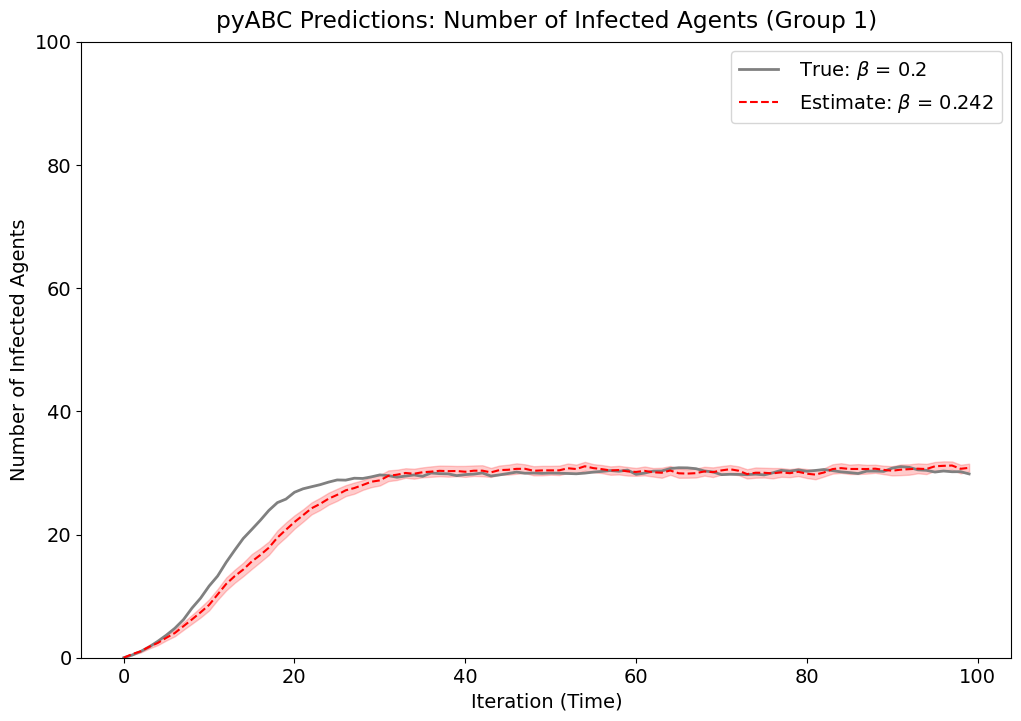

In [17]:
ax = plt.gca()
ax.set_ylim(0,len(model.agents))

#sns.lineplot(data=Dataset, y="num_infected", x = 't', color='red', linewidth=2, errorbar= None)
sns.lineplot(data=True_Data, y="Group1", x = 't', color='grey', errorbar= None, linewidth=2,)
sns.lineplot(data=Estimate, y="Group1", x = 't', color='red',  linestyle='--')

plt.title('pyABC Predictions: Number of Infected Agents (Group 1)', pad=10)
plt.xlabel('Iteration (Time)')
plt.ylabel('Number of Infected Agents')
plt.legend(loc="upper right")
plt.legend([r' True: $\beta$ = 0.2', r' Estimate: $\beta$ = 0.242'])
plt.savefig("Chp_6example-1", bbox_inches="tight", dpi=100)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


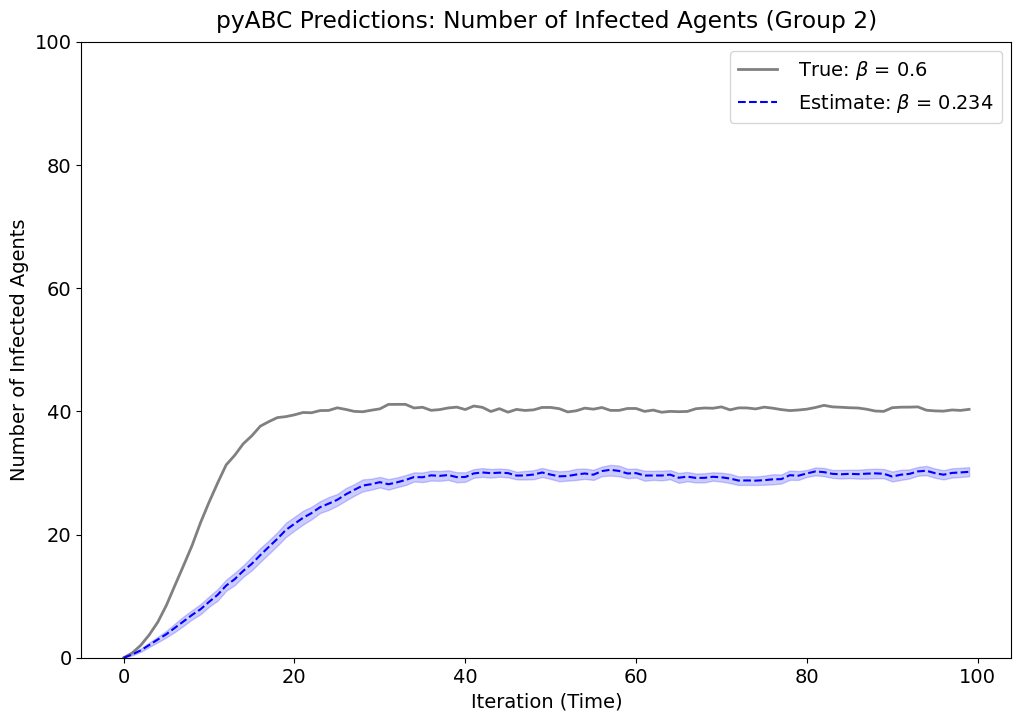

In [91]:
ax = plt.gca()
ax.set_ylim(0,len(model.agents))

#sns.lineplot(data=Dataset, y="num_infected", x = 't', color='red', linewidth=2, errorbar= None)
sns.lineplot(data=True_Data, y="Group2", x = 't' , color='grey', errorbar= None,  linewidth=2)
sns.lineplot(data=Estimate, y="Group2", x = 't' , color='blue',  linestyle='--')

plt.title('pyABC Predictions: Number of Infected Agents (Group 2)', pad=10)
plt.xlabel('Iteration (Time)')
plt.ylabel('Number of Infected Agents')
plt.legend(loc="upper right")
plt.legend([r' True: $\beta$ = 0.6', r' Estimate: $\beta$ = 0.234'])
plt.savefig("Chp_6example-2", bbox_inches="tight", dpi=100)

### Varying Agent Size Group

In [28]:
#pd.set_option('display.max_rows', None) 

In [3]:
df = pd.read_pickle("/Users/deboraholukan/Desktop/test.pkl")

In [4]:
df

,t,group_size,num_infected,Group1,Group1_Av,Group2,Group2_Av,Average,model_number,copy_number
0,0,"[0.0, 1.0]",0.000,0.000,0.000000,0.000,0.785238,0.785238,0,0
1,1,"[0.0, 1.0]",0.147,0.000,0.000000,0.147,0.785238,0.785238,0,0
2,2,"[0.0, 1.0]",0.450,0.000,0.000000,0.450,0.785238,0.785238,0,0
3,3,"[0.0, 1.0]",0.710,0.000,0.000000,0.710,0.785238,0.785238,0,0
4,4,"[0.0, 1.0]",0.792,0.000,0.000000,0.792,0.785238,0.785238,0,0
...,...,...,...,...,...,...,...,...,...,...
1030296,96,"[1.0, 0.0]",0.405,0.405,0.394158,0.000,0.000000,0.394158,100,100
1030297,97,"[1.0, 0.0]",0.406,0.406,0.394158,0.000,0.000000,0.394158,100,100
1030298,98,"[1.0, 0.0]",0.429,0.429,0.394158,0.000,0.000000,0.394158,100,100
1030299,99,"[1.0, 0.0]",0.433,0.433,0.394158,0.000,0.000000,0.394158,100,100


In [5]:
G = df[df['Group2'] == 0]
Group_1 = G[G['Group2_Av'] == 0]
Group_1
# Group_1 = G0[G0['Group1'] != 0]

,t,group_size,num_infected,Group1,Group1_Av,Group2,Group2_Av,Average,model_number,copy_number
10100,0,"[1.0, 0.0]",0.000,0.000,0.404426,0.0,0.0,0.404426,100,0
10101,1,"[1.0, 0.0]",0.124,0.124,0.404426,0.0,0.0,0.404426,100,0
10102,2,"[1.0, 0.0]",0.201,0.201,0.404426,0.0,0.0,0.404426,100,0
10103,3,"[1.0, 0.0]",0.283,0.283,0.404426,0.0,0.0,0.404426,100,0
10104,4,"[1.0, 0.0]",0.296,0.296,0.404426,0.0,0.0,0.404426,100,0
...,...,...,...,...,...,...,...,...,...,...
1030296,96,"[1.0, 0.0]",0.405,0.405,0.394158,0.0,0.0,0.394158,100,100
1030297,97,"[1.0, 0.0]",0.406,0.406,0.394158,0.0,0.0,0.394158,100,100
1030298,98,"[1.0, 0.0]",0.429,0.429,0.394158,0.0,0.0,0.394158,100,100
1030299,99,"[1.0, 0.0]",0.433,0.433,0.394158,0.0,0.0,0.394158,100,100


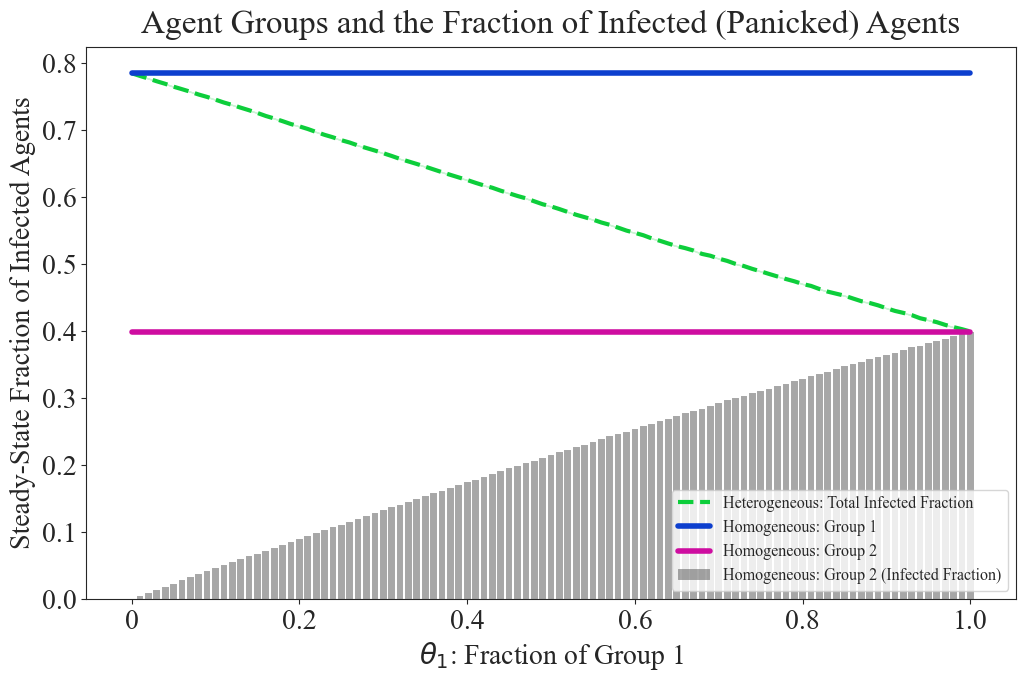

In [15]:
sns.set_style("ticks", {'font.family': 'Times New Roman'})

#lines
sns.lineplot(data=Av, y="Average", x="model_number", color = "#0DCE3B", linestyle='dashed', linewidth=3, label='Heterogeneous: Total Infected Fraction')
 #CE0DA0
sns.lineplot(x = "t", y="Group2_Av",  data=Group_2, color = "#0D3FCE",linewidth=4, label= 'Homogeneous: Group 1')
sns.barplot(data=Av, y="Group1_Av", x="model_number", color="#6C6C6C", linewidth=0.05, errorbar= None, alpha=0.6 , label='Homogeneous: Group 2 (Infected Fraction)')
sns.lineplot(x = "t", y ="Group1_Av", data=Group_1, color = "#CE0DA0",linewidth=4, label= 'Homogeneous: Group 2')

#labels
plt.xlabel(r'$\theta_1$: Fraction of Group 1')
plt.ylabel('Steady-State Fraction of Infected Agents')
plt.subplots_adjust(top=0.8)
#plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.4), fontsize='x-small')
plt.legend(loc="lower right", fontsize='xx-small')
plt.title('Agent Groups and the Fraction of Infected (Panicked) Agents', pad=10)
locs, labels = plt.xticks() 
plt.xticks(np.arange(0, 120, 20), ["0", '0.2', '0.4', '0.6', '0.8', '1.0']) 

plt.savefig("Agent_Group.png", bbox_inches="tight")
plt.show()